In [86]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
import matplotlib.pyplot as plt
from imblearn.over_sampling import RandomOverSampler
from xgboost import XGBClassifier
from sklearn.preprocessing import OrdinalEncoder

In [87]:
data=pd.read_csv("/kaggle/input/datasets/hamzaosamaaboshady/employee-promotion-prediction-csv/employee_promotion_prediction.csv")

In [88]:
data.head(10)

,employee_id,age,gender,education_level,marital_status,city_tier,department,employment_type,years_at_company,years_in_current_role,...,salary,salary_increase_percent,bonus_last_year,stock_options,attendance_rate,late_days,employee_engagement_score,job_satisfaction_score,internal_mobility_score,promoted
0,1,50,Female,Master,Married,Tier1,Finance,Full-time,10,4,...,137633.720337,7.587737,16743.979863,7532.711623,0.930558,1,66.545499,97.588693,39.989458,0
1,2,36,Male,Bachelor,Married,Tier1,Sales,Full-time,9,5,...,114499.406460,10.372718,9074.413744,7694.310517,0.962302,7,81.979508,59.021333,46.484556,0
2,3,29,Female,Bachelor,Married,Tier2,Engineering,Full-time,7,5,...,124233.224752,10.115308,11807.910102,6380.645687,0.891287,1,100.000000,52.992147,38.850858,0
3,4,42,Male,Bachelor,Married,Tier1,Operations,Full-time,4,4,...,100896.326509,9.800044,8496.840118,7046.402195,1.000000,1,67.679942,67.707899,14.262315,0
4,5,40,Female,Master,Married,Tier1,Operations,Full-time,2,2,...,93054.051809,7.501102,15099.354711,4557.907600,0.896275,1,79.903505,64.384274,44.233443,0
5,6,44,Male,Bachelor,Married,Tier3,HR,Contract,2,0,...,78435.738089,8.644923,8215.475835,6322.986021,0.921588,0,71.296509,68.175379,54.806697,1
6,7,32,Female,Bachelor,Single,Tier1,Finance,Full-time,8,4,...,103826.520337,6.985731,13732.084372,8243.583486,0.839941,0,60.479214,82.245338,67.177213,1
7,8,32,Female,Master,Single,Tier2,Marketing,Full-time,3,2,...,98638.617265,5.101447,14984.483913,5855.419750,0.960592,0,87.299344,81.336041,30.719731,0
8,9,45,Male,Bachelor,Single,Tier2,Operations,Full-time,1,0,...,88959.119188,9.324657,11749.456993,5637.202230,0.967944,1,97.618710,77.520189,44.608432,0
9,10,57,Male,Bachelor,Married,Tier3,Engineering,Full-time,7,5,...,106863.600208,6.416611,13372.130771,5847.577665,0.991299,1,68.736037,75.181397,56.196097,0


In [89]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 43 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   employee_id                 100000 non-null  int64  
 1   age                         100000 non-null  int64  
 2   gender                      100000 non-null  object 
 3   education_level             100000 non-null  object 
 4   marital_status              100000 non-null  object 
 5   city_tier                   100000 non-null  object 
 6   department                  100000 non-null  object 
 7   employment_type             100000 non-null  object 
 8   years_at_company            100000 non-null  int64  
 9   years_in_current_role       100000 non-null  int64  
 10  years_since_last_promotion  100000 non-null  int64  
 11  team_size                   100000 non-null  int64  
 12  performance_score           100000 non-null  float64
 13  performance_las

In [90]:
data.isnull().sum()

employee_id                   0
age                           0
gender                        0
education_level               0
marital_status                0
city_tier                     0
department                    0
employment_type               0
years_at_company              0
years_in_current_role         0
years_since_last_promotion    0
team_size                     0
performance_score             0
performance_last_year         0
performance_two_years_ago     0
manager_rating                0
peer_feedback_score           0
projects_completed            0
kpi_achievement_percent       0
innovation_score              0
leadership_score              0
problem_solving_score         0
avg_monthly_hours             0
overtime_hours                0
tasks_completed               0
deadline_adherence_rate       0
meeting_hours_per_month       0
remote_work_ratio             0
training_hours_last_year      0
certifications_count          0
skill_assessment_score        0
cross_de

In [91]:
data.duplicated().sum()

np.int64(0)

In [92]:
data.columns

Index(['employee_id', 'age', 'gender', 'education_level', 'marital_status',
       'city_tier', 'department', 'employment_type', 'years_at_company',
       'years_in_current_role', 'years_since_last_promotion', 'team_size',
       'performance_score', 'performance_last_year',
       'performance_two_years_ago', 'manager_rating', 'peer_feedback_score',
       'projects_completed', 'kpi_achievement_percent', 'innovation_score',
       'leadership_score', 'problem_solving_score', 'avg_monthly_hours',
       'overtime_hours', 'tasks_completed', 'deadline_adherence_rate',
       'meeting_hours_per_month', 'remote_work_ratio',
       'training_hours_last_year', 'certifications_count',
       'skill_assessment_score', 'cross_department_projects',
       'mentoring_sessions', 'salary', 'salary_increase_percent',
       'bonus_last_year', 'stock_options', 'attendance_rate', 'late_days',
       'employee_engagement_score', 'job_satisfaction_score',
       'internal_mobility_score', 'promoted'],


In [93]:
df=data.copy()

In [94]:
df.describe()

,employee_id,age,years_at_company,years_in_current_role,years_since_last_promotion,team_size,performance_score,performance_last_year,performance_two_years_ago,manager_rating,...,salary,salary_increase_percent,bonus_last_year,stock_options,attendance_rate,late_days,employee_engagement_score,job_satisfaction_score,internal_mobility_score,promoted
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,40.558140,5.489030,2.750630,2.749650,11.014010,70.097429,68.166798,65.102153,3.302642,...,101729.791058,7.401439,10409.710839,5658.466284,0.928158,1.993690,69.916845,67.907766,50.011404,0.100000
std,28867.657797,10.951788,3.481758,2.746004,2.733337,4.910633,14.717013,13.867294,11.773939,0.765938,...,36260.885391,2.029034,2311.368587,1264.375203,0.046578,1.415977,14.719348,15.665689,19.714147,0.300002
min,1.000000,22.000000,0.000000,0.000000,0.000000,3.000000,40.000000,40.000000,40.000000,1.000000,...,27616.720722,0.000000,1945.900012,788.905587,0.727631,0.000000,20.000000,20.000000,0.000000,0.000000
25%,25000.750000,31.000000,3.000000,1.000000,1.000000,7.000000,59.499890,58.357646,56.954026,2.769433,...,83242.514699,6.029638,8812.946506,4809.857296,0.896236,1.000000,59.887391,57.184464,36.534728,0.000000
50%,50000.500000,41.000000,5.000000,2.000000,2.000000,11.000000,69.980013,68.033605,65.018847,3.302663,...,96923.478362,7.399610,10410.582882,5661.913481,0.930238,2.000000,70.025028,68.032234,50.043370,0.000000
75%,75000.250000,50.000000,7.000000,4.000000,4.000000,15.000000,80.596442,77.791895,73.121749,3.837462,...,112448.432831,8.773342,12002.845048,6508.183945,0.963801,3.000000,80.159887,78.895916,63.409152,0.000000
max,100000.000000,59.000000,30.000000,28.000000,29.000000,19.000000,100.000000,100.000000,100.000000,5.000000,...,663817.278916,15.996288,19615.455082,10846.763857,1.000000,12.000000,100.000000,100.000000,100.000000,1.000000


------------------------------

$$--Analysis--$$

Top Department's Salary

In [95]:
total_salary_per_department = (
    df.groupby("department", as_index=False)["salary"]
      .sum()
      .sort_values(by="salary", ascending=False)
)

print(total_salary_per_department)

    department        salary
0  Engineering  1.675653e+09
5        Sales  1.571459e+09
1      Finance  1.559651e+09
3    Marketing  1.479491e+09
4   Operations  1.366486e+09
2           HR  1.290725e+09
6      Support  1.229514e+09


performance score Per Department

In [96]:
Top = df.groupby("department")[["performance_score"]].mean()

print(Top)

             performance_score
department                    
Engineering          69.815657
Finance              70.131876
HR                   70.064999
Marketing            69.986469
Operations           70.297093
Sales                70.256751
Support              70.130466


In [97]:
Top_rmp = df[["employee_id","projects_completed","department"]].sort_values(by="projects_completed",ascending=False)

Top_rmp.head()

,employee_id,projects_completed,department
77648,77649,80,Engineering
80009,80010,75,Engineering
95696,95697,75,Engineering
874,875,70,Engineering
79163,79164,70,Engineering


In [98]:
total_salary_per_department = (
    df.groupby("department", as_index=False)[["projects_completed"]]
      .sum()
      .sort_values(by="projects_completed", ascending=False)
)

print(total_salary_per_department)


    department  projects_completed
0  Engineering              120632
3    Marketing               91195
5        Sales               90486
4   Operations               75006
1      Finance               61383
6      Support               60047
2           HR               45725


In [99]:
training_hours_last_year = (
    df.groupby("department")[["training_hours_last_year"]]
      .mean()
      .sort_values(by="training_hours_last_year",ascending=False)
)

print(training_hours_last_year)

             training_hours_last_year
department                           
Finance                     43.444311
Engineering                 43.392755
Marketing                   43.378118
Support                     43.359868
Operations                  43.311354
HR                          43.305234
Sales                       43.270212


In [100]:
Top_Ddepart_Permoted=df.groupby("department",as_index=False)["promoted"].sum().sort_values(by="promoted",ascending=False)
Top_Ddepart_Permoted

,department,promoted
0,Engineering,4713
5,Sales,1561
3,Marketing,1242
1,Finance,1159
4,Operations,628
2,HR,418
6,Support,279


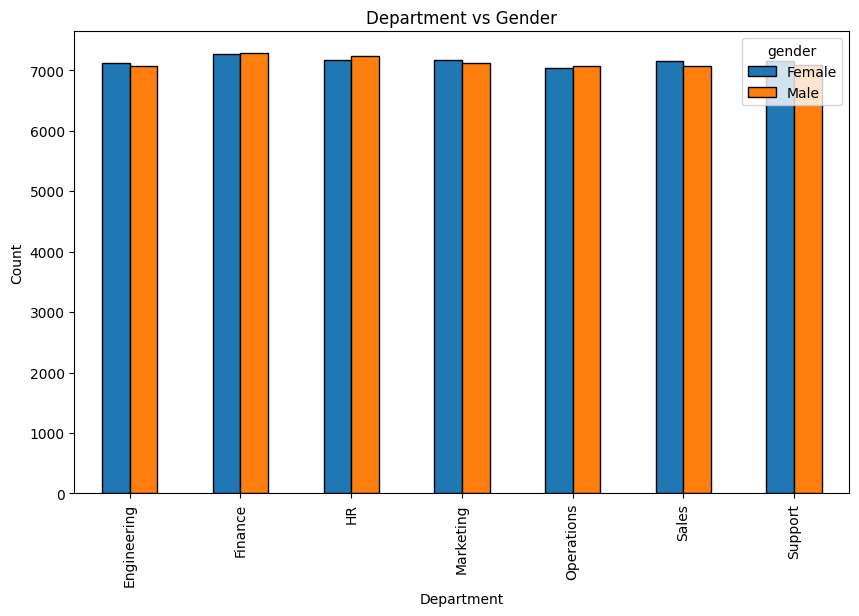

In [101]:
table = pd.crosstab(df["department"], df["gender"])

table.plot(kind="bar", figsize=(10,6), edgecolor="black")

plt.title("Department vs Gender")
plt.xlabel("Department")
plt.ylabel("Count")
plt.show()

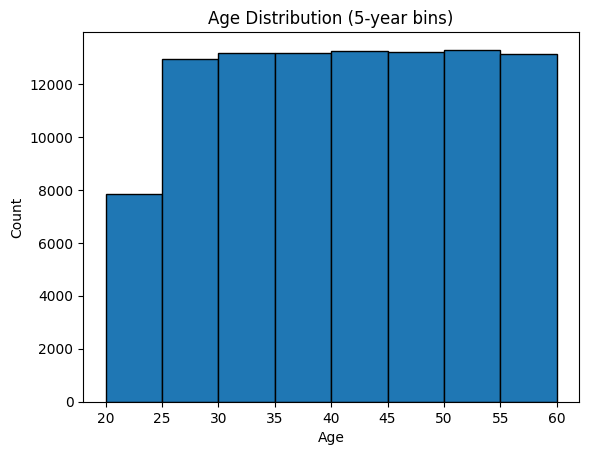

In [102]:
bins = range(20, df["age"].max() + 5, 5)

plt.hist(df["age"], bins=bins, edgecolor='black')
plt.title("Age Distribution (5-year bins)")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

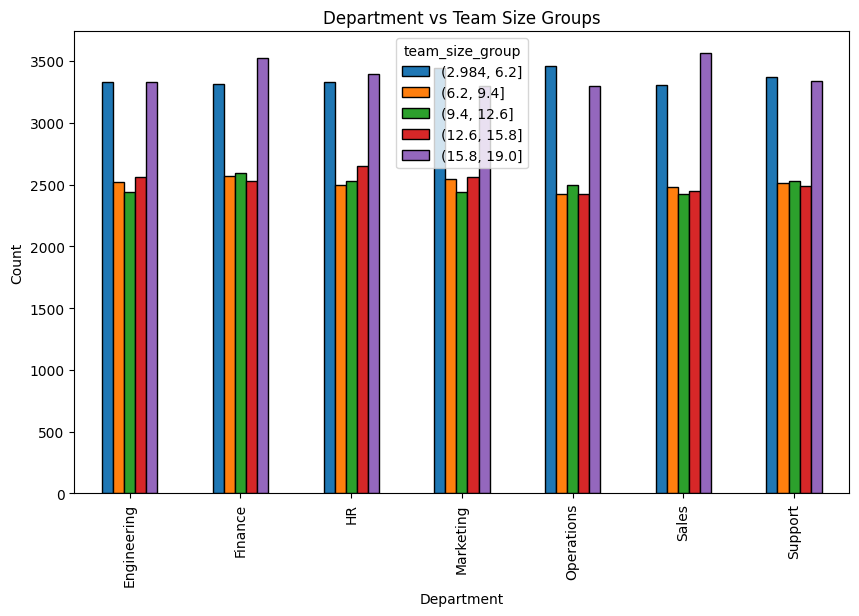

In [103]:
df["team_size_group"] = pd.cut(df["team_size"], bins=5)

table = pd.crosstab(df["department"], df["team_size_group"])

table.plot(kind="bar", figsize=(10,6), edgecolor="black")

plt.title("Department vs Team Size Groups")
plt.xlabel("Department")
plt.ylabel("Count")
plt.show()

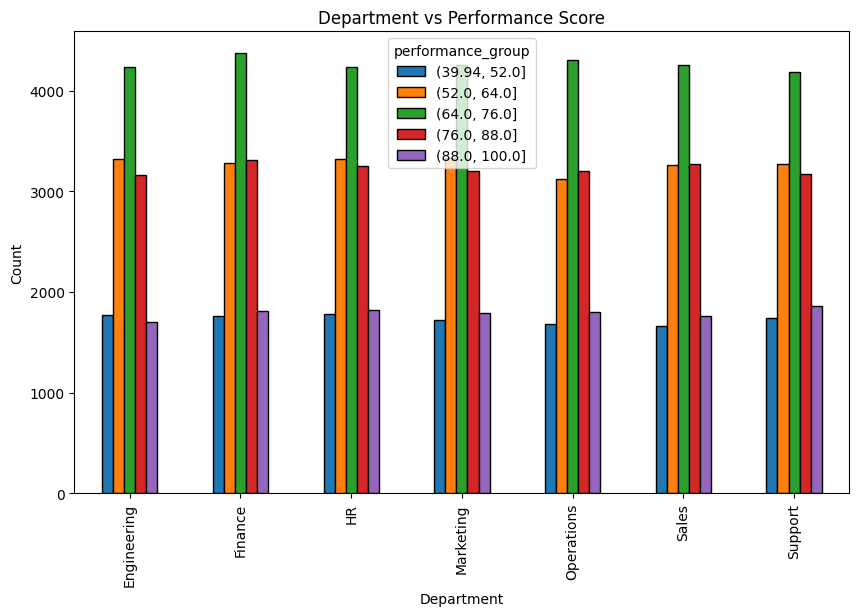

In [104]:
df["performance_group"] = pd.cut(df["performance_score"], bins=5)

table = pd.crosstab(df["department"], df["performance_group"])

table.plot(kind="bar", figsize=(10,6), edgecolor="black")

plt.title("Department vs Performance Score")
plt.xlabel("Department")
plt.ylabel("Count")
plt.show()

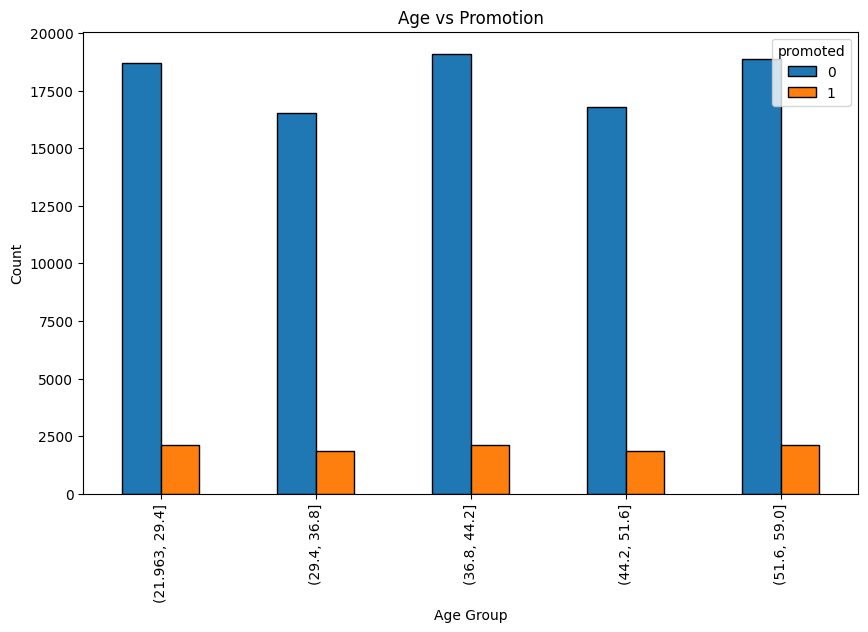

In [105]:
df["age_group"] = pd.cut(df["age"], bins=5)

table = pd.crosstab(df["age_group"], df["promoted"])

table.plot(kind="bar", figsize=(10,6), edgecolor="black")

plt.title("Age vs Promotion")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.show()

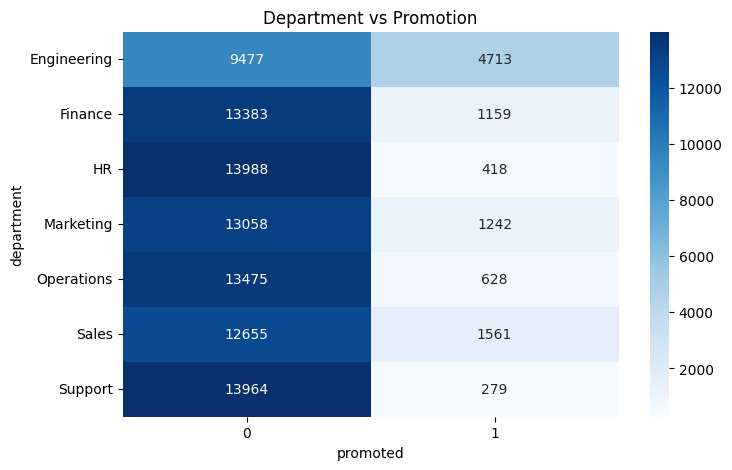

In [106]:
import seaborn as sns
import matplotlib.pyplot as plt

table = pd.crosstab(df["department"], df["promoted"])

plt.figure(figsize=(8,5))
sns.heatmap(table, annot=True, fmt="d", cmap="Blues")

plt.title("Department vs Promotion")
plt.show()

promoted
0    90000
1    10000
Name: count, dtype: int64

promoted
0    0.9
1    0.1
Name: proportion, dtype: float64


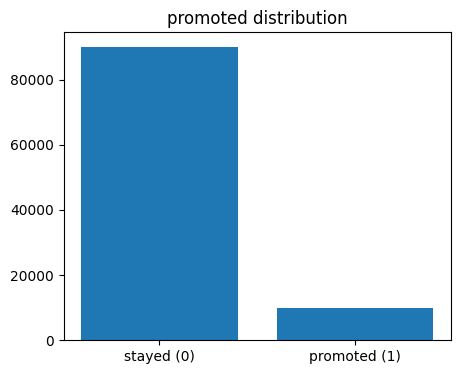

In [107]:
print(df['promoted'].value_counts())
print()
print(df['promoted'].value_counts(normalize=True))

counts = df['promoted'].value_counts().sort_index()
labels = ['stayed (0)', 'promoted (1)']

plt.figure(figsize=(5, 4))
plt.bar(labels, counts.values)
plt.title('promoted distribution')
plt.show()

------------

$$Modling$$

In [108]:

encoder = OrdinalEncoder()


cat_cols = data.select_dtypes(include=['object']).columns
data[cat_cols] = encoder.fit_transform(data[cat_cols])

In [109]:
X = data.drop("promoted", axis=1)
y = data["promoted"]

In [110]:
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
sampler = RandomOverSampler(random_state=42)

In [111]:
thresholds = np.arange(0.1, 1.0, 0.05)

acc_scores = []
pre_scores = []
rec_scores = []
f1_scores = []
auc_scores = []
best_thresholds = []

In [112]:
for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), 1):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    X_train, y_train = sampler.fit_resample(X_train, y_train)

    model = XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    )

    model.fit(X_train, y_train)

    y_prob = model.predict_proba(X_test)[:, 1]

    best_f1 = 0
    best_threshold = 0.5

    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        score = f1_score(y_test, y_pred)

        if score > best_f1:
            best_f1 = score
            best_threshold = t

    y_pred = (y_prob >= best_threshold).astype(int)

    acc_scores.append(accuracy_score(y_test, y_pred))
    pre_scores.append(precision_score(y_test, y_pred))
    rec_scores.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))
    auc_scores.append(roc_auc_score(y_test, y_prob))
    best_thresholds.append(best_threshold)

    print(f"\nFold {fold}")
    print(f"Best Threshold : {best_threshold:.2f}")
    print(f"Accuracy       : {acc_scores[-1]:.4f}")
    print(f"Precision      : {pre_scores[-1]:.4f}")
    print(f"Recall         : {rec_scores[-1]:.4f}")
    print(f"F1 Score       : {f1_scores[-1]:.4f}")
    print(f"ROC-AUC        : {auc_scores[-1]:.4f}")
    print(confusion_matrix(y_test, y_pred))



Fold 1
Best Threshold : 0.75
Accuracy       : 0.9185
Precision      : 0.5848
Recall         : 0.6380
F1 Score       : 0.6102
ROC-AUC        : 0.9334
[[17094   906]
 [  724  1276]]

Fold 2
Best Threshold : 0.70
Accuracy       : 0.9081
Precision      : 0.5307
Recall         : 0.6955
F1 Score       : 0.6020
ROC-AUC        : 0.9354
[[16770  1230]
 [  609  1391]]

Fold 3
Best Threshold : 0.75
Accuracy       : 0.9170
Precision      : 0.5788
Recall         : 0.6240
F1 Score       : 0.6006
ROC-AUC        : 0.9312
[[17092   908]
 [  752  1248]]

Fold 4
Best Threshold : 0.75
Accuracy       : 0.9190
Precision      : 0.5831
Recall         : 0.6650
F1 Score       : 0.6214
ROC-AUC        : 0.9389
[[17049   951]
 [  670  1330]]

Fold 5
Best Threshold : 0.70
Accuracy       : 0.9098
Precision      : 0.5373
Recall         : 0.7055
F1 Score       : 0.6100
ROC-AUC        : 0.9367
[[16785  1215]
 [  589  1411]]


In [113]:
print("\n================ FINAL RESULTS ================")
print("Average Threshold :", np.mean(best_thresholds))
print("Average Accuracy  :", np.mean(acc_scores))
print("Average Precision :", np.mean(pre_scores))
print("Average Recall    :", np.mean(rec_scores))
print("Average F1 Score  :", np.mean(f1_scores))
print("Average ROC-AUC   :", np.mean(auc_scores))


================ FINAL RESULTS ================
Average Threshold : 0.7300000000000002
Average Accuracy  : 0.91446
Average Precision : 0.5629489010407991
Average Recall    : 0.6656000000000001
Average F1 Score  : 0.6088452846551785
Average ROC-AUC   : 0.9351141055555555
